# Pose Clustering v3 — Centroid, RMSD, and Weighted Hybrid

Three distance modes for clustering docked poses:

| Mode          | Distance metric                                      |
|---------------|------------------------------------------------------|
| `centroid`    | Euclidean distance between heavy-atom centroids      |
| `rmsd`        | Heavy-atom RMSD (best-fit via RDKit, fallback atom)  |
| `hybrid`      | `w * norm_rmsd + (1-w) * norm_centroid`              |

Each mode runs K-Medoids (optimal k via silhouette) and Ward
hierarchical clustering independently, per protein-ligand pair.

# Configuration

In [1]:
# ==========================================================================
# USER CONFIGURATION
# ==========================================================================

POSEBUSTERS_CSV = "/home/manndo/master_dev/posebusters_results/mol/posebusters_filtered_results.csv"

# Which docking methods to keep (must match values in the "docking_method" column)
METHODS_TO_INCLUDE = [
    "autodock",
    "diffdock",
    "equibind_guided",
    "equibind_exclusion",
    "equibind_docked_poses",
]

# Output root — sub-directories per mode are created automatically
OUTPUT_DIR = "/home/manndo/master_dev/posebusters_results/clustering_v3_results"

# ---------- Distance mode ----------
# Options: "centroid", "rmsd", "hybrid"
DISTANCE_MODE = "hybrid"

# Weight for hybrid mode: distance = w * norm_rmsd + (1 - w) * norm_centroid
# Ignored unless DISTANCE_MODE == "hybrid"
HYBRID_WEIGHT_RMSD = 0.5

# ---------- Clustering parameters ----------
K_RANGE = range(2, 11)       # range of k to evaluate
RANDOM_STATE = 42
MAX_CENTROID_DIST = 100       # Å — outlier filter

# Imports & Validation

In [2]:
from __future__ import annotations

import math
import re
import warnings
from collections import defaultdict
from itertools import combinations
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    from rdkit import Chem
    from rdkit.Chem import AllChem, rdMolAlign
    RDKIT_AVAILABLE = True
except ImportError:
    RDKIT_AVAILABLE = False
    raise ImportError("RDKit is required.  Install with: conda install -c conda-forge rdkit")

try:
    from sklearn.cluster import AgglomerativeClustering
    from sklearn.metrics import silhouette_score
    from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
    from scipy.spatial.distance import pdist, squareform
    SKLEARN_AVAILABLE = True
except ImportError:
    raise ImportError("scikit-learn and scipy are required.")

try:
    from sklearn_extra.cluster import KMedoids
    KMEDOIDS_AVAILABLE = True
except ImportError:
    KMEDOIDS_AVAILABLE = False
    print("WARNING: sklearn_extra not found — using SimpleKMedoids fallback.")

import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches

# ============================================================================
# Derived constants
# ============================================================================
METHODS_LIST = list(METHODS_TO_INCLUDE)

output_root = Path(OUTPUT_DIR)
output_dir = output_root / DISTANCE_MODE
output_dir.mkdir(parents=True, exist_ok=True)

_PALETTE = ["#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#f39c12", "#1abc9c"]
_MARKERS = ["o", "^", "s", "D", "v", "P"]
METHOD_COLORS  = {m: _PALETTE[i % len(_PALETTE)] for i, m in enumerate(METHODS_LIST)}
METHOD_MARKERS = {m: _MARKERS[i % len(_MARKERS)] for i, m in enumerate(METHODS_LIST)}

print("=" * 100)
print(f"POSE CLUSTERING v3  —  mode = {DISTANCE_MODE.upper()}")
if DISTANCE_MODE == "hybrid":
    print(f"  Hybrid weight:  RMSD × {HYBRID_WEIGHT_RMSD:.2f}  +  Centroid × {1 - HYBRID_WEIGHT_RMSD:.2f}")
print(f"  Output:  {output_dir}")
print("=" * 100)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/manndo/anaconda3/envs/vina/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/manndo/anaconda3/envs/vina/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/manndo/anaconda3/envs/vina/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_lo

POSE CLUSTERING v3  —  mode = HYBRID
  Hybrid weight:  RMSD × 0.50  +  Centroid × 0.50
  Output:  /home/manndo/master_dev/posebusters_results/clustering_v3_results/hybrid


# Load & Filter Data from CSV

In [3]:
# ============================================================================
# LOAD CSV & FILTER  (identical logic to v2)
# ============================================================================

print(f"\nLoading PoseBusters results from:\n  {POSEBUSTERS_CSV}")

df_raw = pd.read_csv(POSEBUSTERS_CSV)
print(f"  Total rows in CSV: {len(df_raw)}")

df_raw = df_raw[df_raw["docking_method"].isin(METHODS_TO_INCLUDE)].copy()
print(f"  Rows after filtering to {METHODS_TO_INCLUDE}: {len(df_raw)}")

if df_raw.empty:
    raise RuntimeError(
        f"No rows for docking_method in {METHODS_TO_INCLUDE}.\n"
        f"Available: {sorted(pd.read_csv(POSEBUSTERS_CSV)['docking_method'].unique())}"
    )

# ── Identify boolean PoseBusters test columns ────────────────────────────
_exclude_cols = {
    'mol_true_loaded', 'mol_cond_loaded',
    'number_short_outlier_bonds', 'number_long_outlier_bonds',
    'number_outlier_angles', 'number_clashes',
    'number_non-aromatic_rings_pass', 'number_aromatic_rings_pass',
    'number_non-aromatic_rings_checked', 'number_aromatic_rings_checked',
    'number_double_bonds_checked', 'number_double_bonds_pass',
    'number_valid_bonds', 'number_valid_angles', 'number_valid_noncov_pairs',
    'number_noncov_pairs', 'number_bonds', 'number_angles',
    'num_h_added',
}
_meta_cols = {
    'file_path', 'filepath', 'file', 'path', 'sdf_file', 'sdf_path',
    'method', 'docking_method', 'protein', 'ligand', 'pose_rank', 'rank',
    'molecule', 'mol_name', 'name', 'complex', 'protein_path', 'ligand_path',
    'mol_pred', 'mol_true', 'mol_cond', 'pose_file', 'pose_name',
    'file_format', 'protein_file_used', 'posebusters_mode',
    'diffdock_confidence',
}
_numeric_cols = {
    'mol_pred_energy', 'ensemble_avg_energy', 'energy_ratio',
    'shortest_bond_relative_length', 'longest_bond_relative_length',
    'most_extreme_relative_angle',
    'shortest_noncovalent_relative_distance',
    'aromatic_ring_maximum_distance_from_plane',
    'non-aromatic_ring_maximum_distance_from_plane',
    'double_bond_maximum_distance_from_plane',
}

test_cols = []
for col in df_raw.columns:
    cl = col.lower().strip()
    if cl in _meta_cols or col in _exclude_cols:
        continue
    if cl.startswith("number_") or cl.startswith("num_"):
        continue
    if cl in _numeric_cols:
        continue
    uv = df_raw[col].dropna().unique()
    if set(uv).issubset({True, False, 1, 0, 1.0, 0.0, "True", "False", "true", "false"}):
        test_cols.append(col)

print(f"  Boolean test columns detected ({len(test_cols)}): {test_cols}")

for tc in test_cols:
    if df_raw[tc].dtype == object:
        df_raw[tc] = df_raw[tc].map({"True": True, "true": True, "False": False, "false": False})
    df_raw[tc] = df_raw[tc].astype(bool)

df_raw["all_passed"] = df_raw[test_cols].all(axis=1)
df_passed = df_raw[df_raw["all_passed"]].copy()
print(f"  Poses passing ALL PoseBusters tests: {len(df_passed)} / {len(df_raw)}")

for m in METHODS_TO_INCLUDE:
    nm = (df_passed["docking_method"] == m).sum()
    nt = (df_raw["docking_method"] == m).sum()
    print(f"    {m}: {nm} passed / {nt} total")


Loading PoseBusters results from:
  /home/manndo/master_dev/posebusters_results/mol/posebusters_filtered_results.csv
  Total rows in CSV: 9885
  Rows after filtering to ['autodock', 'diffdock', 'equibind_guided', 'equibind_exclusion', 'equibind_docked_poses']: 9885
  Boolean test columns detected (15): ['mol_pred_loaded', 'sanitization', 'inchi_convertible', 'all_atoms_connected', 'no_radicals', 'bond_lengths', 'bond_angles', 'internal_steric_clash', 'aromatic_ring_flatness', 'non-aromatic_ring_non-flatness', 'double_bond_flatness', 'internal_energy', 'passes_valence_checks', 'passes_kekulization', 'no_radicals_before_sanitization']
  Poses passing ALL PoseBusters tests: 7457 / 9885
    autodock: 720 passed / 960 total
    diffdock: 1082 passed / 1489 total
    equibind_guided: 5084 passed / 6633 total
    equibind_exclusion: 499 passed / 700 total
    equibind_docked_poses: 72 passed / 103 total


# Feature Extraction — Centroids & Heavy-Atom Coords

In [4]:
# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def _extract_rank(pose_name: str) -> int:
    """Extract numeric rank from a pose_name string."""
    if pd.isna(pose_name):
        return 1
    s = str(pose_name)
    for pat in (r"rank(\d+)", r"pose(\d+)", r"model(\d+)"):
        m = re.search(pat, s)
        if m:
            return int(m.group(1))
    return 1


def load_heavy_atom_mol(sdf_path: str) -> Optional[Chem.Mol]:
    """Load an SDF and return a heavy-atom-only mol (or None)."""
    try:
        mol = Chem.MolFromMolFile(sdf_path, removeHs=True, sanitize=False)
        if mol is None:
            mol = Chem.MolFromMolFile(sdf_path, removeHs=False, sanitize=False)
            if mol is not None:
                mol = Chem.RemoveHs(mol)
        if mol is None or mol.GetNumConformers() == 0:
            return None
        return mol
    except Exception:
        return None


def heavy_atom_coords(mol: Chem.Mol) -> np.ndarray:
    """Return (N, 3) heavy-atom coordinate array."""
    conf = mol.GetConformer()
    return np.array([
        [conf.GetAtomPosition(i).x, conf.GetAtomPosition(i).y, conf.GetAtomPosition(i).z]
        for i in range(mol.GetNumAtoms())
    ])


def centroid_from_mol(mol: Chem.Mol) -> np.ndarray:
    """Return (3,) centroid vector from heavy atoms."""
    return heavy_atom_coords(mol).mean(axis=0)


def compute_heavy_atom_rmsd(mol_a: Chem.Mol, mol_b: Chem.Mol) -> float:
    """Best-fit heavy-atom RMSD via RDKit; fallback to centroid distance."""
    try:
        if mol_a.GetNumAtoms() == mol_b.GetNumAtoms():
            return rdMolAlign.GetBestRMS(mol_a, mol_b)
        else:
            # Atom count mismatch — fall back to centroid-centroid distance
            return float(np.linalg.norm(
                centroid_from_mol(mol_a) - centroid_from_mol(mol_b)
            ))
    except Exception:
        try:
            return float(np.linalg.norm(
                centroid_from_mol(mol_a) - centroid_from_mol(mol_b)
            ))
        except Exception:
            return np.nan


# ============================================================================
# EXTRACT FEATURES PER POSE
# ============================================================================

print("\n" + "=" * 100)
print("Extracting heavy-atom features from PoseBusters-PASSED poses ...")
print("=" * 100)

all_poses: List[dict] = []
loaded_mols: Dict[str, Chem.Mol] = {}   # keyed by file_path
n_ok = {m: 0 for m in METHODS_TO_INCLUDE}
n_fail = {m: 0 for m in METHODS_TO_INCLUDE}

for _, row in df_passed.iterrows():
    method = row["docking_method"]
    protein = re.sub(r"_cleaned$", "", str(row["protein"]))
    ligand = row["ligand"]
    pose_file = str(row["pose_file"])
    pose_name = row.get("pose_name", "")
    rank = _extract_rank(pose_name)

    if not Path(pose_file).exists():
        n_fail[method] += 1
        continue

    mol = load_heavy_atom_mol(pose_file)
    if mol is None:
        n_fail[method] += 1
        continue

    centroid = centroid_from_mol(mol)
    n_ok[method] += 1
    loaded_mols[pose_file] = mol
    all_poses.append({
        "method": method,
        "protein": protein,
        "ligand": ligand,
        "pose_rank": rank,
        "file_path": pose_file,
        "centroid_x": centroid[0],
        "centroid_y": centroid[1],
        "centroid_z": centroid[2],
    })

df_poses = pd.DataFrame(all_poses)

print(f"\n  Feature extraction summary:")
for m in METHODS_TO_INCLUDE:
    print(f"    {m}: {n_ok[m]} ok / {n_fail[m]} failed")
print(f"  Total poses loaded: {len(df_poses)}")
if not df_poses.empty:
    print(f"  Unique protein-ligand combos: {df_poses.groupby(['protein', 'ligand']).ngroups}")

# ── Outlier removal ──
n_before = len(df_poses)
keep = pd.Series(True, index=df_poses.index)
for (protein, ligand), grp in df_poses.groupby(["protein", "ligand"]):
    med = grp[["centroid_x", "centroid_y", "centroid_z"]].median().values
    d = np.linalg.norm(grp[["centroid_x", "centroid_y", "centroid_z"]].values - med, axis=1)
    bad = d > MAX_CENTROID_DIST
    if bad.any():
        keep.loc[grp.index[bad]] = False
        for i, idx in enumerate(grp.index[bad]):
            r = df_poses.loc[idx]
            print(f"    OUTLIER: {r['method']} rank {r['pose_rank']} "
                  f"({r['protein']}+{r['ligand']}), dist={d[np.where(bad)[0][i]]:.0f} Å")
df_poses = df_poses[keep].reset_index(drop=True)
n_removed = n_before - len(df_poses)
if n_removed:
    print(f"  Removed {n_removed} outliers (>{MAX_CENTROID_DIST} Å from median)")


Extracting heavy-atom features from PoseBusters-PASSED poses ...

  Feature extraction summary:
    autodock: 720 ok / 0 failed
    diffdock: 1082 ok / 0 failed
    equibind_guided: 5084 ok / 0 failed
    equibind_exclusion: 499 ok / 0 failed
    equibind_docked_poses: 72 ok / 0 failed
  Total poses loaded: 7457
  Unique protein-ligand combos: 16
    OUTLIER: diffdock rank 26 (Orai1WT-MDSnap-Fr300+2abp-nh2-OPT), dist=228 Å
    OUTLIER: diffdock rank 27 (Orai1WT-MDSnap-Fr300+2abp-nh2-OPT), dist=1262 Å
    OUTLIER: diffdock rank 28 (Orai1WT-MDSnap-Fr300+2abp-nh2-OPT), dist=153 Å
    OUTLIER: diffdock rank 29 (Orai1WT-MDSnap-Fr300+2abp-nh2-OPT), dist=28899 Å
    OUTLIER: diffdock rank 27 (Orai1WT-MDSnap-Fr300+2abp-nh2-OPT), dist=290076 Å
    OUTLIER: diffdock rank 28 (Orai1WT-MDSnap-Fr300+2abp-nh2-OPT), dist=119 Å
    OUTLIER: diffdock rank 29 (Orai1WT-MDSnap-Fr300+2abp-nh2-OPT), dist=1620 Å
    OUTLIER: diffdock rank 29 (Orai1WT-MDSnap-Fr300+2abp-nh2-OPT), dist=392 Å
    OUTLIER: diffdo

# Distance Matrix Construction

In [5]:
# ============================================================================
# BUILD DISTANCE MATRICES  (per protein-ligand combination)
# ============================================================================
#
# For each protein-ligand group the script computes:
#   centroid_dist[i,j] = Euclidean distance between centroid_i and centroid_j
#   rmsd_dist[i,j]     = Heavy-atom RMSD between pose_i and pose_j
#   hybrid_dist[i,j]   = w * norm(rmsd) + (1-w) * norm(centroid)
#
# Only the matrix required by the chosen DISTANCE_MODE is actually used for
# clustering, but all three are computed so they can be compared.
# ============================================================================

import sys
from functools import lru_cache


def _pairwise_centroid_dm(centroids: np.ndarray) -> np.ndarray:
    """Euclidean distance matrix from (N,3) centroid array."""
    return squareform(pdist(centroids, metric="euclidean"))


def _pairwise_rmsd_dm(file_paths: List[str], mol_cache: Dict[str, Chem.Mol]) -> np.ndarray:
    """Full N×N heavy-atom RMSD distance matrix."""
    n = len(file_paths)
    dm = np.zeros((n, n))
    for i in range(n):
        mol_i = mol_cache.get(file_paths[i])
        if mol_i is None:
            dm[i, :] = np.nan
            continue
        for j in range(i + 1, n):
            mol_j = mol_cache.get(file_paths[j])
            if mol_j is None:
                dm[i, j] = dm[j, i] = np.nan
                continue
            r = compute_heavy_atom_rmsd(mol_i, mol_j)
            dm[i, j] = dm[j, i] = r
    return dm


def _normalise(dm: np.ndarray) -> np.ndarray:
    """Min-max normalise a distance matrix to [0, 1]."""
    finite = dm[np.isfinite(dm)]
    if len(finite) == 0:
        return np.zeros_like(dm)
    lo, hi = finite.min(), finite.max()
    if hi - lo < 1e-12:
        return np.zeros_like(dm)
    out = (dm - lo) / (hi - lo)
    out[~np.isfinite(out)] = 1.0  # NaN → max distance
    return out


def build_distance_matrix(
    group_df: pd.DataFrame,
    mol_cache: Dict[str, Chem.Mol],
    mode: str = "centroid",
    w_rmsd: float = 0.5,
) -> np.ndarray:
    """Return the distance matrix for the requested mode.

    Parameters
    ----------
    group_df : DataFrame with centroid_x/y/z and file_path columns.
    mol_cache : dict mapping file_path → RDKit Mol.
    mode : "centroid", "rmsd", or "hybrid".
    w_rmsd : weight for RMSD in hybrid mode (0–1).

    Returns
    -------
    dm : (N, N) numpy distance matrix.
    """
    centroids = group_df[["centroid_x", "centroid_y", "centroid_z"]].values
    file_paths = group_df["file_path"].tolist()

    if mode == "centroid":
        return _pairwise_centroid_dm(centroids)

    if mode == "rmsd":
        return _pairwise_rmsd_dm(file_paths, mol_cache)

    if mode == "hybrid":
        dm_c = _pairwise_centroid_dm(centroids)
        dm_r = _pairwise_rmsd_dm(file_paths, mol_cache)
        nc = _normalise(dm_c)
        nr = _normalise(dm_r)
        return w_rmsd * nr + (1.0 - w_rmsd) * nc

    raise ValueError(f"Unknown distance mode: {mode!r}")


print(f"\nDistance mode:  {DISTANCE_MODE}")
if DISTANCE_MODE == "hybrid":
    print(f"  Formula:  {HYBRID_WEIGHT_RMSD:.2f} × norm(RMSD) + {1 - HYBRID_WEIGHT_RMSD:.2f} × norm(Centroid)")


Distance mode:  hybrid
  Formula:  0.50 × norm(RMSD) + 0.50 × norm(Centroid)


# Clustering Engines

In [6]:
# ============================================================================
# CLUSTERING ENGINES
# ============================================================================


class SimpleKMedoids:
    """PAM-style K-Medoids fallback when sklearn_extra is absent."""
    def __init__(self, n_clusters=3, max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.labels_ = None
        self.cluster_centers_ = None
        self.medoid_indices_ = None
        self.inertia_ = None

    def fit(self, dm: np.ndarray):
        """Fit on a precomputed distance matrix."""
        np.random.seed(self.random_state)
        n = dm.shape[0]
        meds = np.random.choice(n, self.n_clusters, replace=False)
        for _ in range(self.max_iter):
            labels = np.argmin(dm[:, meds], axis=1)
            new_meds = meds.copy()
            for k in range(self.n_clusters):
                members = np.where(labels == k)[0]
                if len(members) == 0:
                    continue
                sub = dm[np.ix_(members, members)]
                new_meds[k] = members[np.argmin(sub.sum(axis=1))]
            if np.array_equal(meds, new_meds):
                break
            meds = new_meds
        self.medoid_indices_ = meds
        self.labels_ = np.argmin(dm[:, meds], axis=1)
        self.inertia_ = sum(dm[i, meds[self.labels_[i]]] for i in range(n))
        return self

    def fit_predict(self, dm: np.ndarray) -> np.ndarray:
        self.fit(dm)
        return self.labels_


def _kmedoids_with_dm(dm: np.ndarray, k: int, random_state: int = 42):
    """Run K-Medoids on a precomputed distance matrix."""
    if KMEDOIDS_AVAILABLE:
        model = KMedoids(n_clusters=k, metric="precomputed",
                         random_state=random_state, method="pam")
        labels = model.fit_predict(dm)
        inertia = model.inertia_
    else:
        model = SimpleKMedoids(n_clusters=k, random_state=random_state)
        labels = model.fit_predict(dm)
        inertia = model.inertia_
    return labels, inertia


def find_optimal_k_kmedoids(dm: np.ndarray, k_range, random_state=42):
    """Sweep k and pick the one with the best silhouette score."""
    n = dm.shape[0]
    results = {"k": [], "silhouette": [], "inertia": []}
    for k in k_range:
        if k >= n:
            break
        labels, inertia = _kmedoids_with_dm(dm, k, random_state)
        sil = silhouette_score(dm, labels, metric="precomputed") if len(set(labels)) > 1 else -1
        results["k"].append(k)
        results["silhouette"].append(sil)
        results["inertia"].append(inertia)
    if not results["k"]:
        return {"optimal_k": 1, "best_silhouette": -1, "k": [], "silhouette": [], "inertia": []}
    best_idx = int(np.argmax(results["silhouette"]))
    results["optimal_k"] = results["k"][best_idx]
    results["best_silhouette"] = results["silhouette"][best_idx]
    return results


def find_optimal_k_ward(centroids: np.ndarray, k_range):
    """Ward clustering uses Euclidean coordinates (always centroid-based internally)."""
    results = {"k": [], "silhouette": [], "inertia": []}
    for k in k_range:
        if k >= len(centroids):
            break
        model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        labels = model.fit_predict(centroids)
        sil = silhouette_score(centroids, labels) if len(set(labels)) > 1 else -1
        # pseudo-inertia: sum of within-cluster distances to centroid
        inertia = 0.0
        for c in set(labels):
            members = centroids[labels == c]
            center = members.mean(axis=0)
            inertia += np.sum(np.linalg.norm(members - center, axis=1) ** 2)
        results["k"].append(k)
        results["silhouette"].append(sil)
        results["inertia"].append(inertia)
    if not results["k"]:
        return {"optimal_k": 1, "best_silhouette": -1, "k": [], "silhouette": [], "inertia": []}
    best_idx = int(np.argmax(results["silhouette"]))
    results["optimal_k"] = results["k"][best_idx]
    results["best_silhouette"] = results["silhouette"][best_idx]
    return results


def ward_on_dm(dm: np.ndarray, k: int) -> np.ndarray:
    """Ward-like agglomerative clustering on a precomputed distance matrix.

    Ward linkage proper requires Euclidean coordinates, so when the distance
    matrix comes from RMSD or Hybrid mode we use *average* linkage instead
    (which accepts precomputed distances) as the best hierarchical analogue.
    """
    condensed = squareform(dm, checks=False)
    Z = linkage(condensed, method="average")
    return fcluster(Z, t=k, criterion="maxclust") - 1   # 0-indexed


def find_optimal_k_hierarchical_dm(dm: np.ndarray, k_range):
    """Hierarchical clustering on precomputed distance matrix (average linkage)."""
    n = dm.shape[0]
    results = {"k": [], "silhouette": [], "inertia": []}
    for k in k_range:
        if k >= n:
            break
        labels = ward_on_dm(dm, k)
        sil = silhouette_score(dm, labels, metric="precomputed") if len(set(labels)) > 1 else -1
        results["k"].append(k)
        results["silhouette"].append(sil)
        results["inertia"].append(0.0)
    if not results["k"]:
        return {"optimal_k": 1, "best_silhouette": -1, "k": [], "silhouette": [], "inertia": []}
    best_idx = int(np.argmax(results["silhouette"]))
    results["optimal_k"] = results["k"][best_idx]
    results["best_silhouette"] = results["silhouette"][best_idx]
    return results


print("Clustering engines loaded.")

Clustering engines loaded.


# Shared Stats & Overlap Helpers

In [7]:
# ============================================================================
# SHARED HELPERS
# ============================================================================

def compute_cluster_stats(df: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    """Compute cluster centers, sizes, and radii."""
    rows = []
    for (protein, ligand, cid), grp in df.groupby(["protein", "ligand", cluster_col]):
        coords = grp[["centroid_x", "centroid_y", "centroid_z"]].values
        center = coords.mean(axis=0)
        radius = float(np.max(np.linalg.norm(coords - center, axis=1))) if len(coords) > 1 else 0.0
        mc = grp["method"].value_counts().to_dict()
        row = {
            "protein": protein, "ligand": ligand, "cluster_id": cid,
            "cluster_method": cluster_col.replace("cluster_", ""),
            "n_poses": len(grp),
            "center_x": center[0], "center_y": center[1], "center_z": center[2],
            "radius_A": round(radius, 2),
        }
        for m in METHODS_LIST:
            row[m] = mc.get(m, 0)
        row["n_methods"] = len(mc)
        row["methods_present"] = ", ".join(sorted(mc.keys()))
        rows.append(row)
    return pd.DataFrame(rows)


def identify_pocket_overlap(df_stats: pd.DataFrame) -> pd.DataFrame:
    out = []
    for _, row in df_stats.iterrows():
        present = [m for m in METHODS_LIST if row.get(m, 0) > 0]
        if len(present) >= 2:
            ptype = "Overlapping"
        elif len(present) == 1:
            ptype = f"Unique ({present[0]})"
        else:
            ptype = "Empty"
        out.append({**row.to_dict(), "pocket_type": ptype, "n_methods_in_pocket": len(present)})
    return pd.DataFrame(out)


def score_conformity(group_df: pd.DataFrame, cluster_col: str) -> dict:
    """Composite conformity score (higher = more agreement across methods)."""
    nc = group_df[cluster_col].nunique()
    nm = group_df["method"].nunique()
    np_ = len(group_df)

    overlap_poses = 0
    overlap_clusters = 0
    for _, cg in group_df.groupby(cluster_col):
        if cg["method"].nunique() >= 2:
            overlap_clusters += 1
            overlap_poses += len(cg)
    frac = overlap_poses / np_ if np_ else 0

    method_cents = {}
    for method, mg in group_df.groupby("method"):
        method_cents[method] = mg[["centroid_x", "centroid_y", "centroid_z"]].values.mean(axis=0)
    imd = [np.linalg.norm(c1 - c2) for (_, c1), (_, c2) in combinations(method_cents.items(), 2)]
    mean_imd = float(np.mean(imd)) if imd else 0.0

    all_c = group_df[["centroid_x", "centroid_y", "centroid_z"]].values
    spread = float(np.mean(np.linalg.norm(all_c - all_c.mean(axis=0), axis=1)))

    cscore = (
        frac * 0.4
        + max(0, 1 - mean_imd / 50) * 0.3
        + max(0, 1 - spread / 30) * 0.2
        + max(0, 1 - nc / 10) * 0.1
    )
    return {
        "n_clusters": nc, "n_methods": nm, "n_poses": np_,
        "overlapping_clusters": overlap_clusters,
        "overlap_fraction": round(frac, 3),
        "mean_inter_method_dist": round(mean_imd, 2),
        "spatial_spread": round(spread, 2),
        "conformity_score": round(cscore, 4),
    }


print("Shared helper functions loaded.")

Shared helper functions loaded.


# Run Clustering

In [8]:
# ============================================================================
# MAIN CLUSTERING LOOP
# ============================================================================

if df_poses.empty:
    raise RuntimeError("No poses available after filtering.")

print("\n" + "=" * 100)
print(f"CLUSTERING  —  mode = {DISTANCE_MODE.upper()}")
print("=" * 100)

df_clust = df_poses.copy()
df_clust["cluster_kmedoids"] = -1
df_clust["cluster_hierarchical"] = -1

km_info: Dict[str, dict] = {}
hi_info: Dict[str, dict] = {}

combo_groups = list(df_clust.groupby(["protein", "ligand"]))
n_combos = len(combo_groups)

for gi, ((protein, ligand), grp) in enumerate(combo_groups, 1):
    combo_key = f"{protein}__{ligand}"
    idx = grp.index
    n_poses = len(grp)

    print(f"\n  [{gi}/{n_combos}] {combo_key}  ({n_poses} poses)")

    # ── Trivial case ──
    if n_poses < 3:
        df_clust.loc[idx, "cluster_kmedoids"] = 0
        df_clust.loc[idx, "cluster_hierarchical"] = 0
        km_info[combo_key] = {"n_poses": n_poses, "optimal_k": 1, "best_silhouette": -1, "search_results": None}
        hi_info[combo_key] = {"n_poses": n_poses, "optimal_k": 1, "best_silhouette": -1, "search_results": None}
        print(f"    → <3 poses, assigning to cluster 0")
        continue

    # ── Build distance matrix ──
    dm = build_distance_matrix(grp, loaded_mols, mode=DISTANCE_MODE, w_rmsd=HYBRID_WEIGHT_RMSD)

    # Handle NaN in dm (replace with max finite value)
    finite_vals = dm[np.isfinite(dm)]
    if len(finite_vals) == 0:
        print(f"    ⚠ Distance matrix is all NaN — skipping")
        df_clust.loc[idx, "cluster_kmedoids"] = 0
        df_clust.loc[idx, "cluster_hierarchical"] = 0
        km_info[combo_key] = {"n_poses": n_poses, "optimal_k": 1, "best_silhouette": -1, "search_results": None}
        hi_info[combo_key] = {"n_poses": n_poses, "optimal_k": 1, "best_silhouette": -1, "search_results": None}
        continue
    dm[~np.isfinite(dm)] = finite_vals.max()

    max_k = min(max(K_RANGE), n_poses - 1)
    actual_range = range(2, max_k + 1)
    if len(actual_range) == 0:
        df_clust.loc[idx, "cluster_kmedoids"] = 0
        df_clust.loc[idx, "cluster_hierarchical"] = 0
        km_info[combo_key] = {"n_poses": n_poses, "optimal_k": 1, "best_silhouette": -1, "search_results": None}
        hi_info[combo_key] = {"n_poses": n_poses, "optimal_k": 1, "best_silhouette": -1, "search_results": None}
        continue

    # ── K-Medoids (precomputed distance matrix) ──
    km_res = find_optimal_k_kmedoids(dm, actual_range, RANDOM_STATE)
    k_opt_km = km_res["optimal_k"]
    labels_km, _ = _kmedoids_with_dm(dm, k_opt_km, RANDOM_STATE)
    df_clust.loc[idx, "cluster_kmedoids"] = labels_km
    km_info[combo_key] = {
        "n_poses": n_poses, "optimal_k": k_opt_km,
        "best_silhouette": km_res["best_silhouette"],
        "search_results": km_res,
    }
    print(f"    K-Medoids: k={k_opt_km}  sil={km_res['best_silhouette']:.3f}")

    # ── Hierarchical ──
    if DISTANCE_MODE == "centroid":
        # Pure centroid mode → use proper Ward linkage on coordinates
        centroids = grp[["centroid_x", "centroid_y", "centroid_z"]].values
        hi_res = find_optimal_k_ward(centroids, actual_range)
        k_opt_hi = hi_res["optimal_k"]
        model_hi = AgglomerativeClustering(n_clusters=k_opt_hi, linkage="ward")
        labels_hi = model_hi.fit_predict(centroids)
    else:
        # RMSD or Hybrid → average-linkage on precomputed DM
        hi_res = find_optimal_k_hierarchical_dm(dm, actual_range)
        k_opt_hi = hi_res["optimal_k"]
        labels_hi = ward_on_dm(dm, k_opt_hi)

    df_clust.loc[idx, "cluster_hierarchical"] = labels_hi
    hi_info[combo_key] = {
        "n_poses": n_poses, "optimal_k": k_opt_hi,
        "best_silhouette": hi_res["best_silhouette"],
        "search_results": hi_res,
    }
    print(f"    Hierarchical: k={k_opt_hi}  sil={hi_res['best_silhouette']:.3f}")

df_clust["cluster_kmedoids"] = df_clust["cluster_kmedoids"].astype(int)
df_clust["cluster_hierarchical"] = df_clust["cluster_hierarchical"].astype(int)

print("\n" + "=" * 100)
print("CLUSTERING COMPLETE")
print("=" * 100)


CLUSTERING  —  mode = HYBRID

  [1/16] Orai1WT-MDSnap-Fr300__2abp-nh2-OPT  (671 poses)
    K-Medoids: k=2  sil=0.633
    Hierarchical: k=2  sil=0.704

  [2/16] Orai1WT-MDSnap-Fr300__Synta-66-OPT-Singlet  (617 poses)
    K-Medoids: k=3  sil=0.608
    Hierarchical: k=4  sil=0.624

  [3/16] Orai1WT-MDSnap-Fr300__gsk7975a-deprot-OPT  (104 poses)
    K-Medoids: k=2  sil=0.380
    Hierarchical: k=5  sil=0.410

  [4/16] Orai1WT-MDSnap-Fr300__gsk7975a-prot-OPT  (585 poses)
    K-Medoids: k=3  sil=0.506
    Hierarchical: k=6  sil=0.664

  [5/16] Orai1WT-MDSnap-Fr400__2abp-nh2-OPT  (570 poses)
    K-Medoids: k=2  sil=0.588
    Hierarchical: k=2  sil=0.660

  [6/16] Orai1WT-MDSnap-Fr400__Synta-66-OPT-Singlet  (601 poses)
    K-Medoids: k=2  sil=0.580
    Hierarchical: k=4  sil=0.621

  [7/16] Orai1WT-MDSnap-Fr400__gsk7975a-deprot-OPT  (109 poses)
    K-Medoids: k=10  sil=0.421
    Hierarchical: k=2  sil=0.410

  [8/16] Orai1WT-MDSnap-Fr400__gsk7975a-prot-OPT  (588 poses)
    K-Medoids: k=2  sil=

# Results Summary

In [9]:
# ============================================================================
# RESULTS TABLES
# ============================================================================

print(f"\n{'='*100}")
print(f"K-MEDOIDS RESULTS  (mode={DISTANCE_MODE})")
print(f"{'='*100}")
print(f"  {'Protein-Ligand':<55} {'k':>5} {'Silhouette':>12} {'Poses':>8}")
print("  " + "-" * 85)
for ck, info in sorted(km_info.items()):
    print(f"  {ck:<55} {info['optimal_k']:>5} {info['best_silhouette']:>12.3f} {info['n_poses']:>8}")

df_km_stats = compute_cluster_stats(df_clust, "cluster_kmedoids")
df_km_overlap = identify_pocket_overlap(df_km_stats)

print(f"\n{'='*100}")
print("K-MEDOIDS — Binding Pocket Clusters")
print(f"{'='*100}")
km_display_cols = ["protein", "ligand", "cluster_id", "n_poses", "radius_A"] + \
                  METHODS_LIST + ["pocket_type", "n_methods_in_pocket"]
print(df_km_overlap[km_display_cols].sort_values(["protein", "ligand", "cluster_id"]).to_string(index=False))

# ── Pocket overlap summary ──
print(f"\n{'='*100}")
print("K-MEDOIDS — Overlapping vs Unique")
print(f"{'='*100}")
agg_dict = {"n_poses": ["count", "sum"]}
for m in METHODS_LIST:
    agg_dict[m] = "sum"
ps = df_km_overlap.groupby("pocket_type").agg(agg_dict)
ps.columns = ["N_Clusters", "Total_Poses"] + [f"{m}_Poses" for m in METHODS_LIST]
ps = ps.reset_index()
print(ps.to_string(index=False))

# ── Hierarchical ──
print(f"\n{'='*100}")
print(f"HIERARCHICAL RESULTS  (mode={DISTANCE_MODE})")
print(f"{'='*100}")
print(f"  {'Protein-Ligand':<55} {'k':>5} {'Silhouette':>12} {'Poses':>8}")
print("  " + "-" * 85)
for ck, info in sorted(hi_info.items()):
    print(f"  {ck:<55} {info['optimal_k']:>5} {info['best_silhouette']:>12.3f} {info['n_poses']:>8}")

df_hi_stats = compute_cluster_stats(df_clust, "cluster_hierarchical")
df_hi_overlap = identify_pocket_overlap(df_hi_stats)

print(f"\n{'='*100}")
print("HIERARCHICAL — Binding Pocket Clusters")
print(f"{'='*100}")
hi_display_cols = ["protein", "ligand", "cluster_id", "n_poses", "radius_A"] + \
                  METHODS_LIST + ["pocket_type", "n_methods_in_pocket"]
print(df_hi_overlap[hi_display_cols].sort_values(["protein", "ligand", "cluster_id"]).to_string(index=False))


K-MEDOIDS RESULTS  (mode=hybrid)
  Protein-Ligand                                              k   Silhouette    Poses
  -------------------------------------------------------------------------------------
  Orai1WT-MDSnap-Fr300__2abp-nh2-OPT                          2        0.633      671
  Orai1WT-MDSnap-Fr300__Synta-66-OPT-Singlet                  3        0.608      617
  Orai1WT-MDSnap-Fr300__gsk7975a-deprot-OPT                   2        0.380      104
  Orai1WT-MDSnap-Fr300__gsk7975a-prot-OPT                     3        0.506      585
  Orai1WT-MDSnap-Fr400__2abp-nh2-OPT                          2        0.588      570
  Orai1WT-MDSnap-Fr400__Synta-66-OPT-Singlet                  2        0.580      601
  Orai1WT-MDSnap-Fr400__gsk7975a-deprot-OPT                  10        0.421      109
  Orai1WT-MDSnap-Fr400__gsk7975a-prot-OPT                     2        0.362      588
  Orai1WT-MDSnap-Fr499__2abp-nh2-OPT                          2        0.612      552
  Orai1WT-MDSnap-F

# Conformity Scoring

In [10]:
# ============================================================================
# CONFORMITY / DIVERSITY SCORING
# ============================================================================

print(f"\n{'='*100}")
print("CONFORMITY SCORING")
print(f"{'='*100}")

score_rows = []
for (protein, ligand), grp in df_clust.groupby(["protein", "ligand"]):
    s_km = score_conformity(grp, "cluster_kmedoids")
    s_hi = score_conformity(grp, "cluster_hierarchical")
    # Average of both clusterers
    avg_score = round((s_km["conformity_score"] + s_hi["conformity_score"]) / 2, 4)
    score_rows.append({
        "protein": protein, "ligand": ligand,
        "n_poses": s_km["n_poses"], "n_methods": s_km["n_methods"],
        "km_k": km_info.get(f"{protein}__{ligand}", {}).get("optimal_k", 1),
        "km_sil": km_info.get(f"{protein}__{ligand}", {}).get("best_silhouette", -1),
        "km_conformity": s_km["conformity_score"],
        "hi_k": hi_info.get(f"{protein}__{ligand}", {}).get("optimal_k", 1),
        "hi_sil": hi_info.get(f"{protein}__{ligand}", {}).get("best_silhouette", -1),
        "hi_conformity": s_hi["conformity_score"],
        "avg_conformity": avg_score,
        "overlap_frac": s_km["overlap_fraction"],
        "mean_inter_method_dist": s_km["mean_inter_method_dist"],
        "spatial_spread": s_km["spatial_spread"],
    })

df_scores = pd.DataFrame(score_rows).sort_values("avg_conformity", ascending=False)
print(df_scores.to_string(index=False))


CONFORMITY SCORING
             protein               ligand  n_poses  n_methods  km_k   km_sil  km_conformity  hi_k   hi_sil  hi_conformity  avg_conformity  overlap_frac  mean_inter_method_dist  spatial_spread
Orai1WT-MDSnap-Fr400         2abp-nh2-OPT      570          5     2 0.588253         0.7615     2 0.659879         0.7594          0.7604         1.000                   16.36           18.06
   Orai1WT-START-Fr0 Synta-66-OPT-Singlet      547          5     2 0.618644         0.7900     5 0.647094         0.7037          0.7469         1.000                   14.98           15.01
   Orai1WT-START-Fr0    gsk7975a-prot-OPT      503          4     2 0.637707         0.7694     3 0.648467         0.7236          0.7465         1.000                   19.85           13.72
Orai1WT-MDSnap-Fr499 Synta-66-OPT-Singlet      619          5     2 0.527424         0.7719     6 0.553947         0.6938          0.7329         1.000                   16.15           16.68
Orai1WT-MDSnap-Fr499

# Silhouette Search Plots

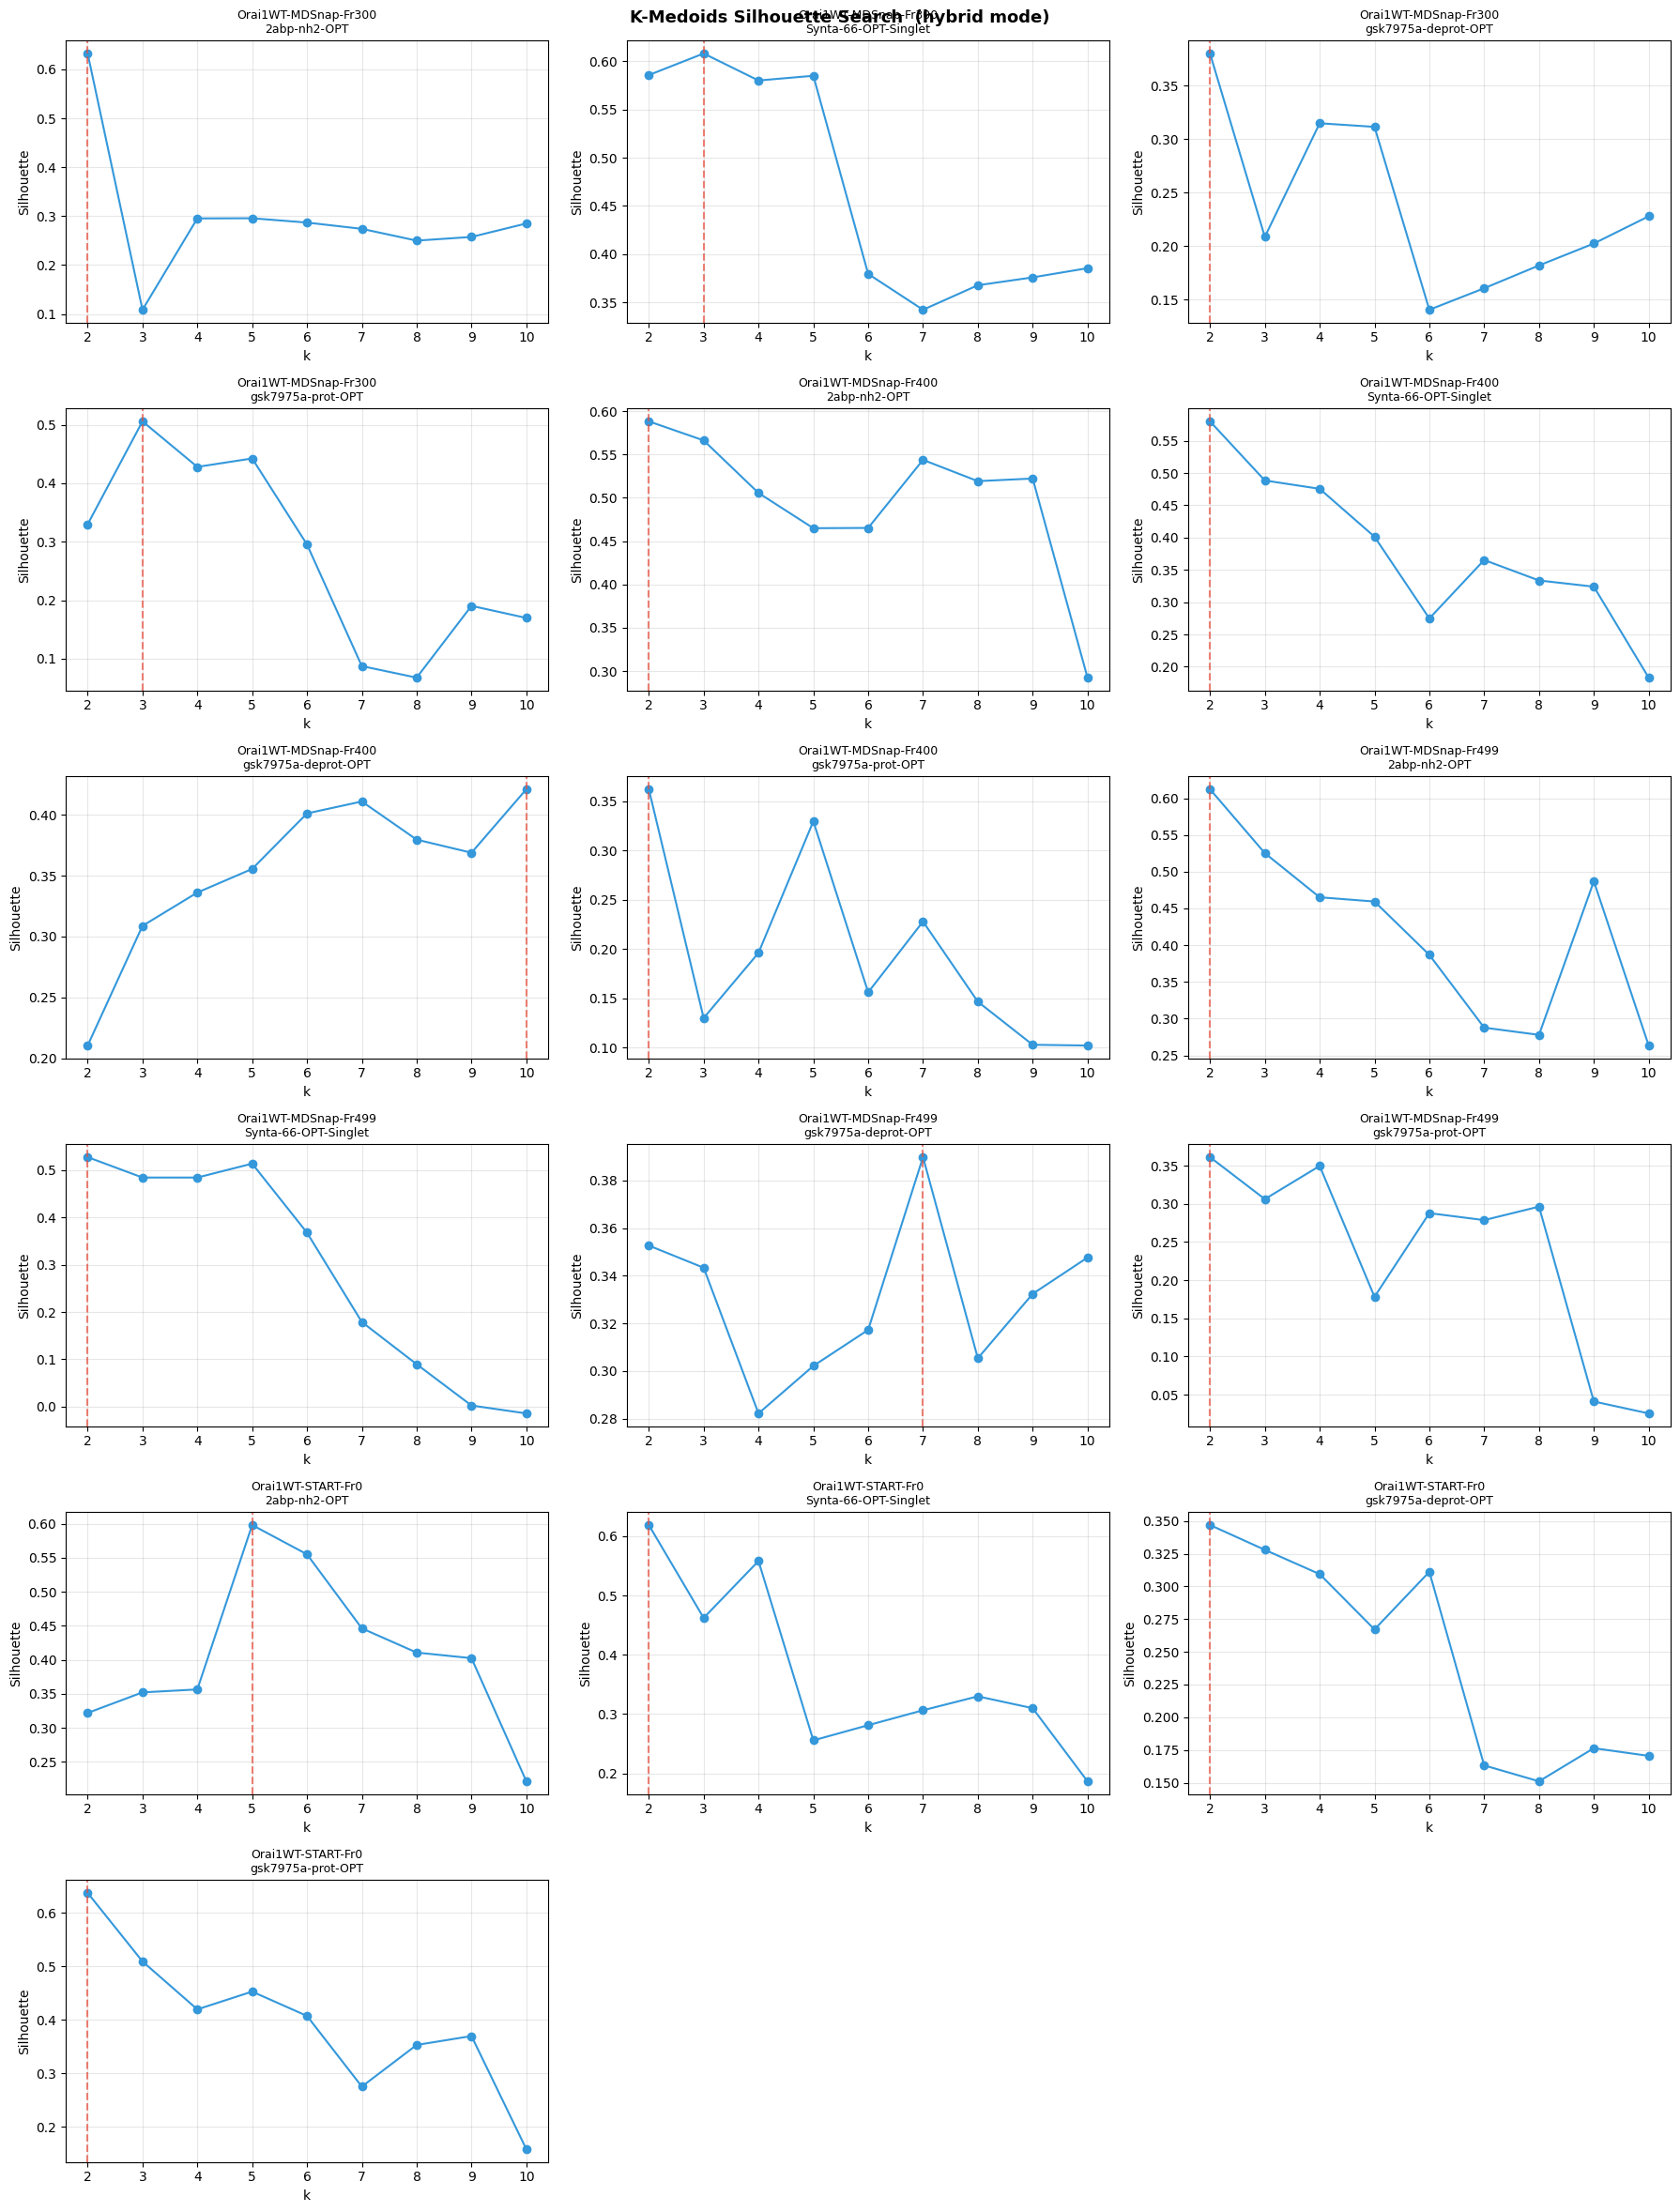

In [11]:
# ============================================================================
# SILHOUETTE SCORE SEARCH PLOTS
# ============================================================================

combos_with_search = [(k, v) for k, v in km_info.items() if v.get("search_results")]
n_plots = len(combos_with_search)

if n_plots > 0:
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for i, (ck, info) in enumerate(combos_with_search):
        ax = axes_flat[i]
        sr = info["search_results"]
        ax.plot(sr["k"], sr["silhouette"], "o-", color="#3498db")
        ax.axvline(sr["optimal_k"], ls="--", color="#e74c3c", alpha=0.7)
        ax.set_title(ck.replace("__", "\n"), fontsize=9)
        ax.set_xlabel("k"); ax.set_ylabel("Silhouette")
        ax.grid(alpha=0.3)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(f"K-Medoids Silhouette Search  ({DISTANCE_MODE} mode)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(output_dir / "silhouette_search_kmedoids.png", dpi=150, bbox_inches="tight")
    plt.show()

# 3D Scatter Visualisation

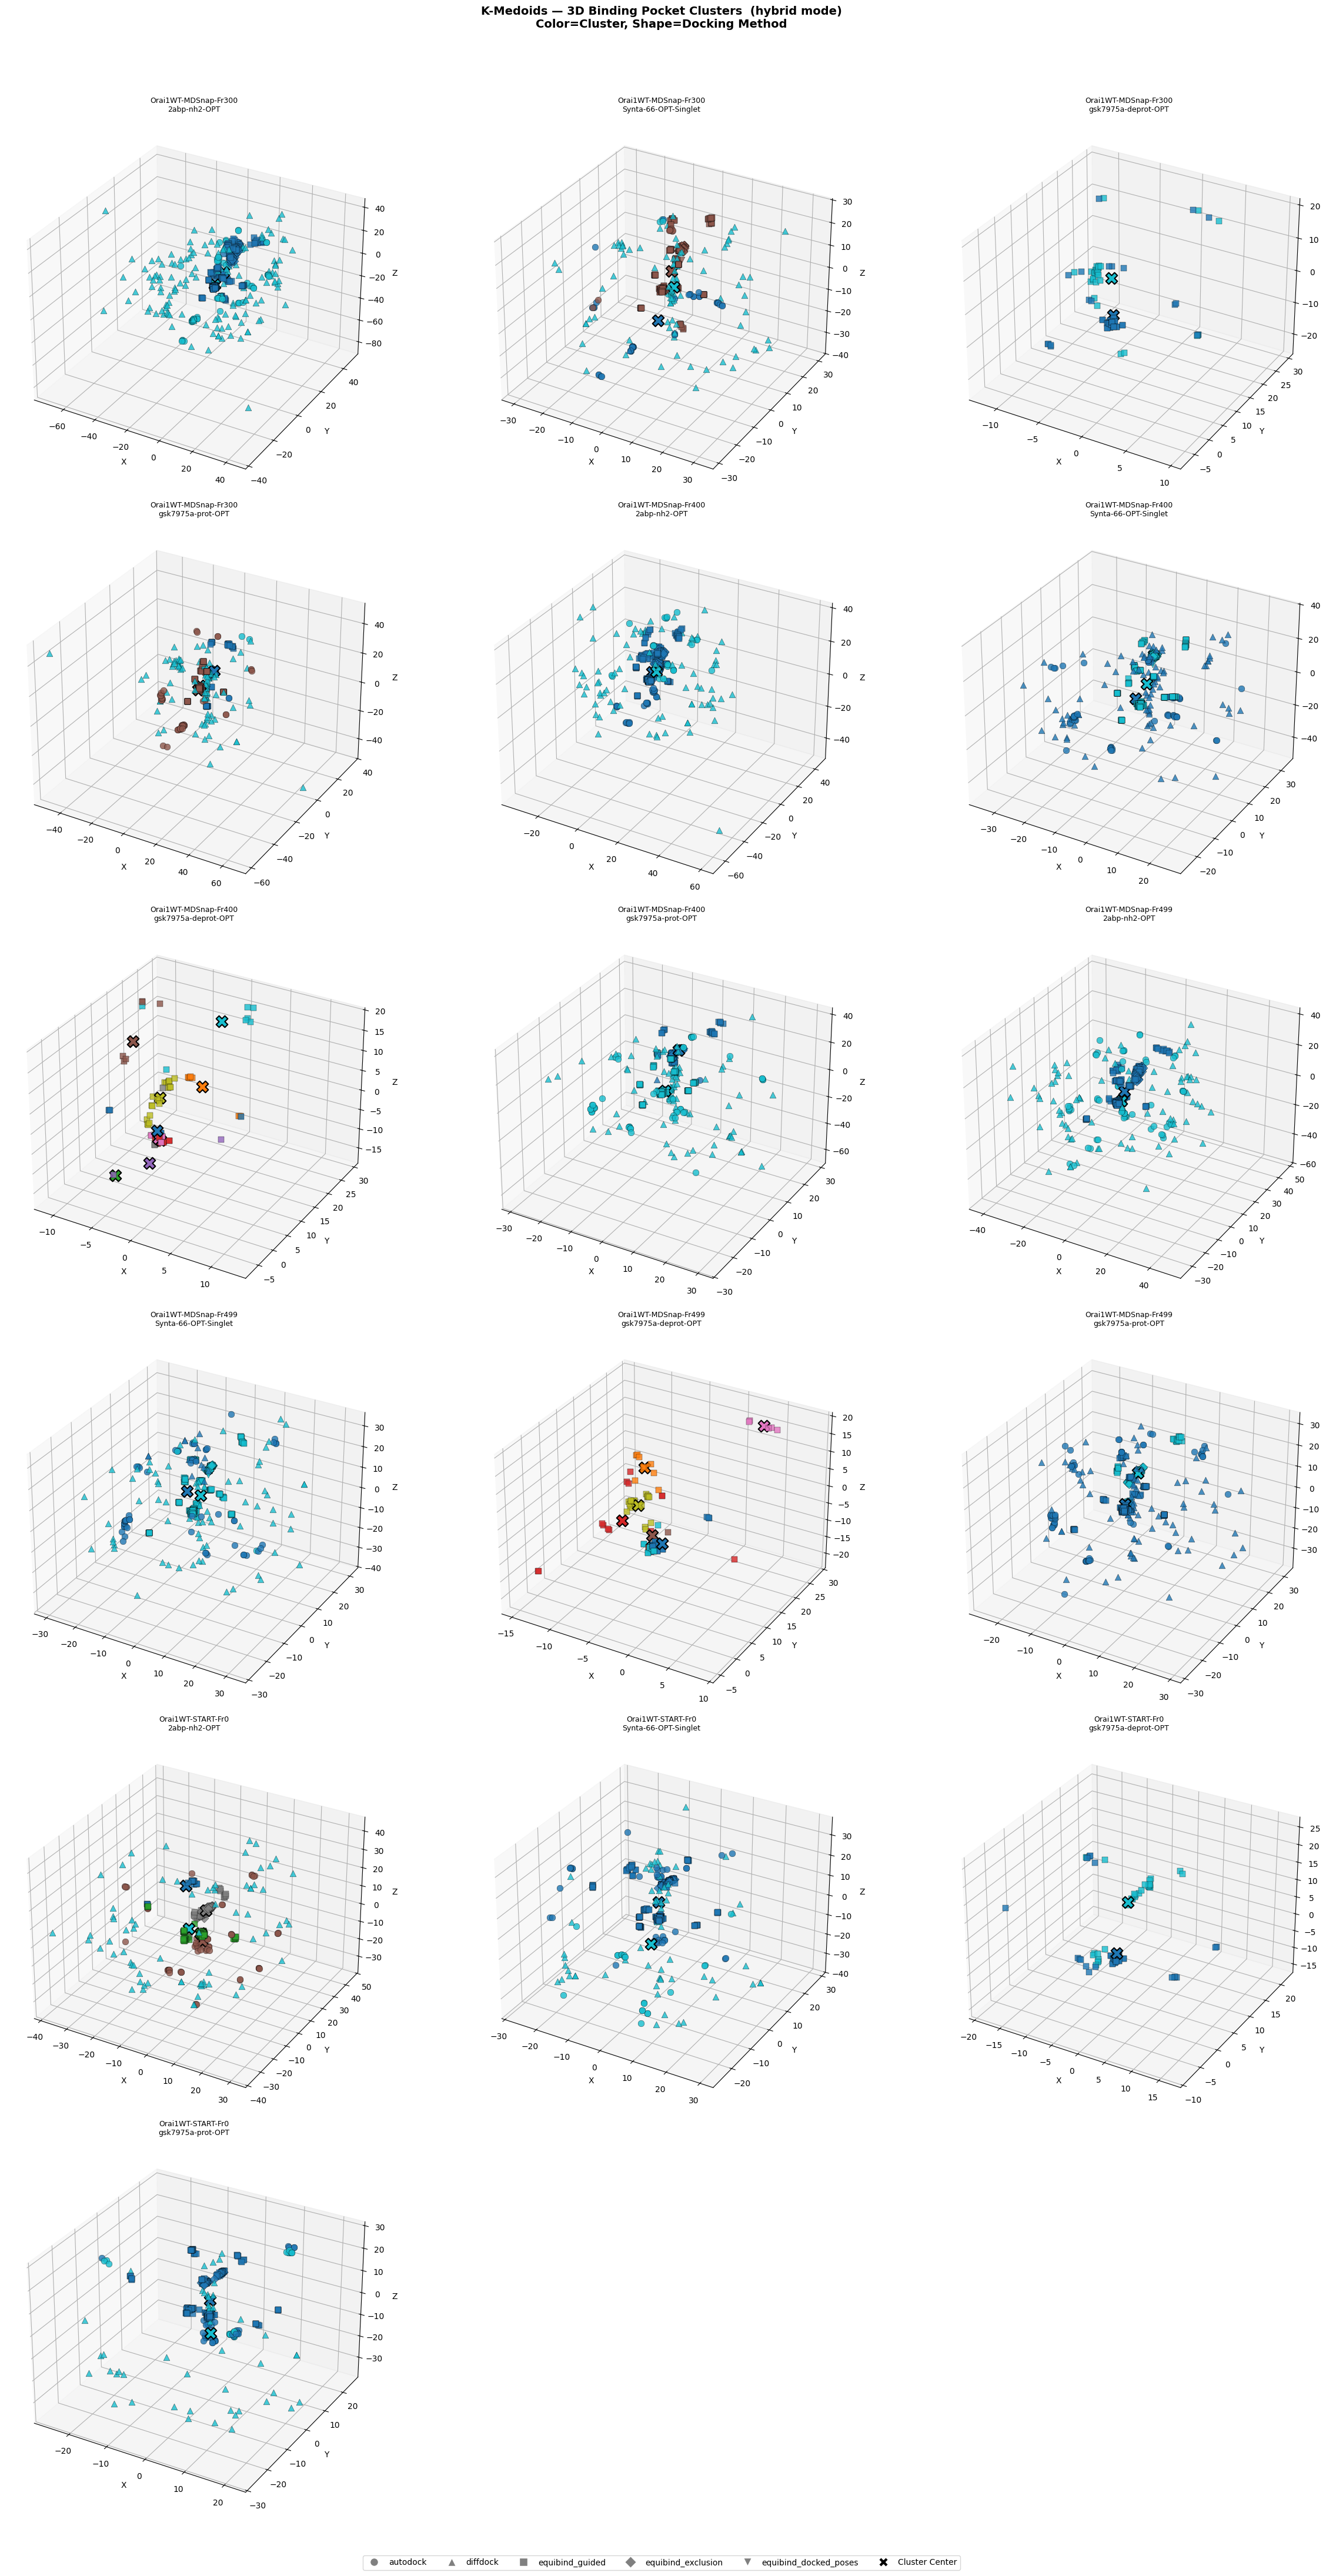

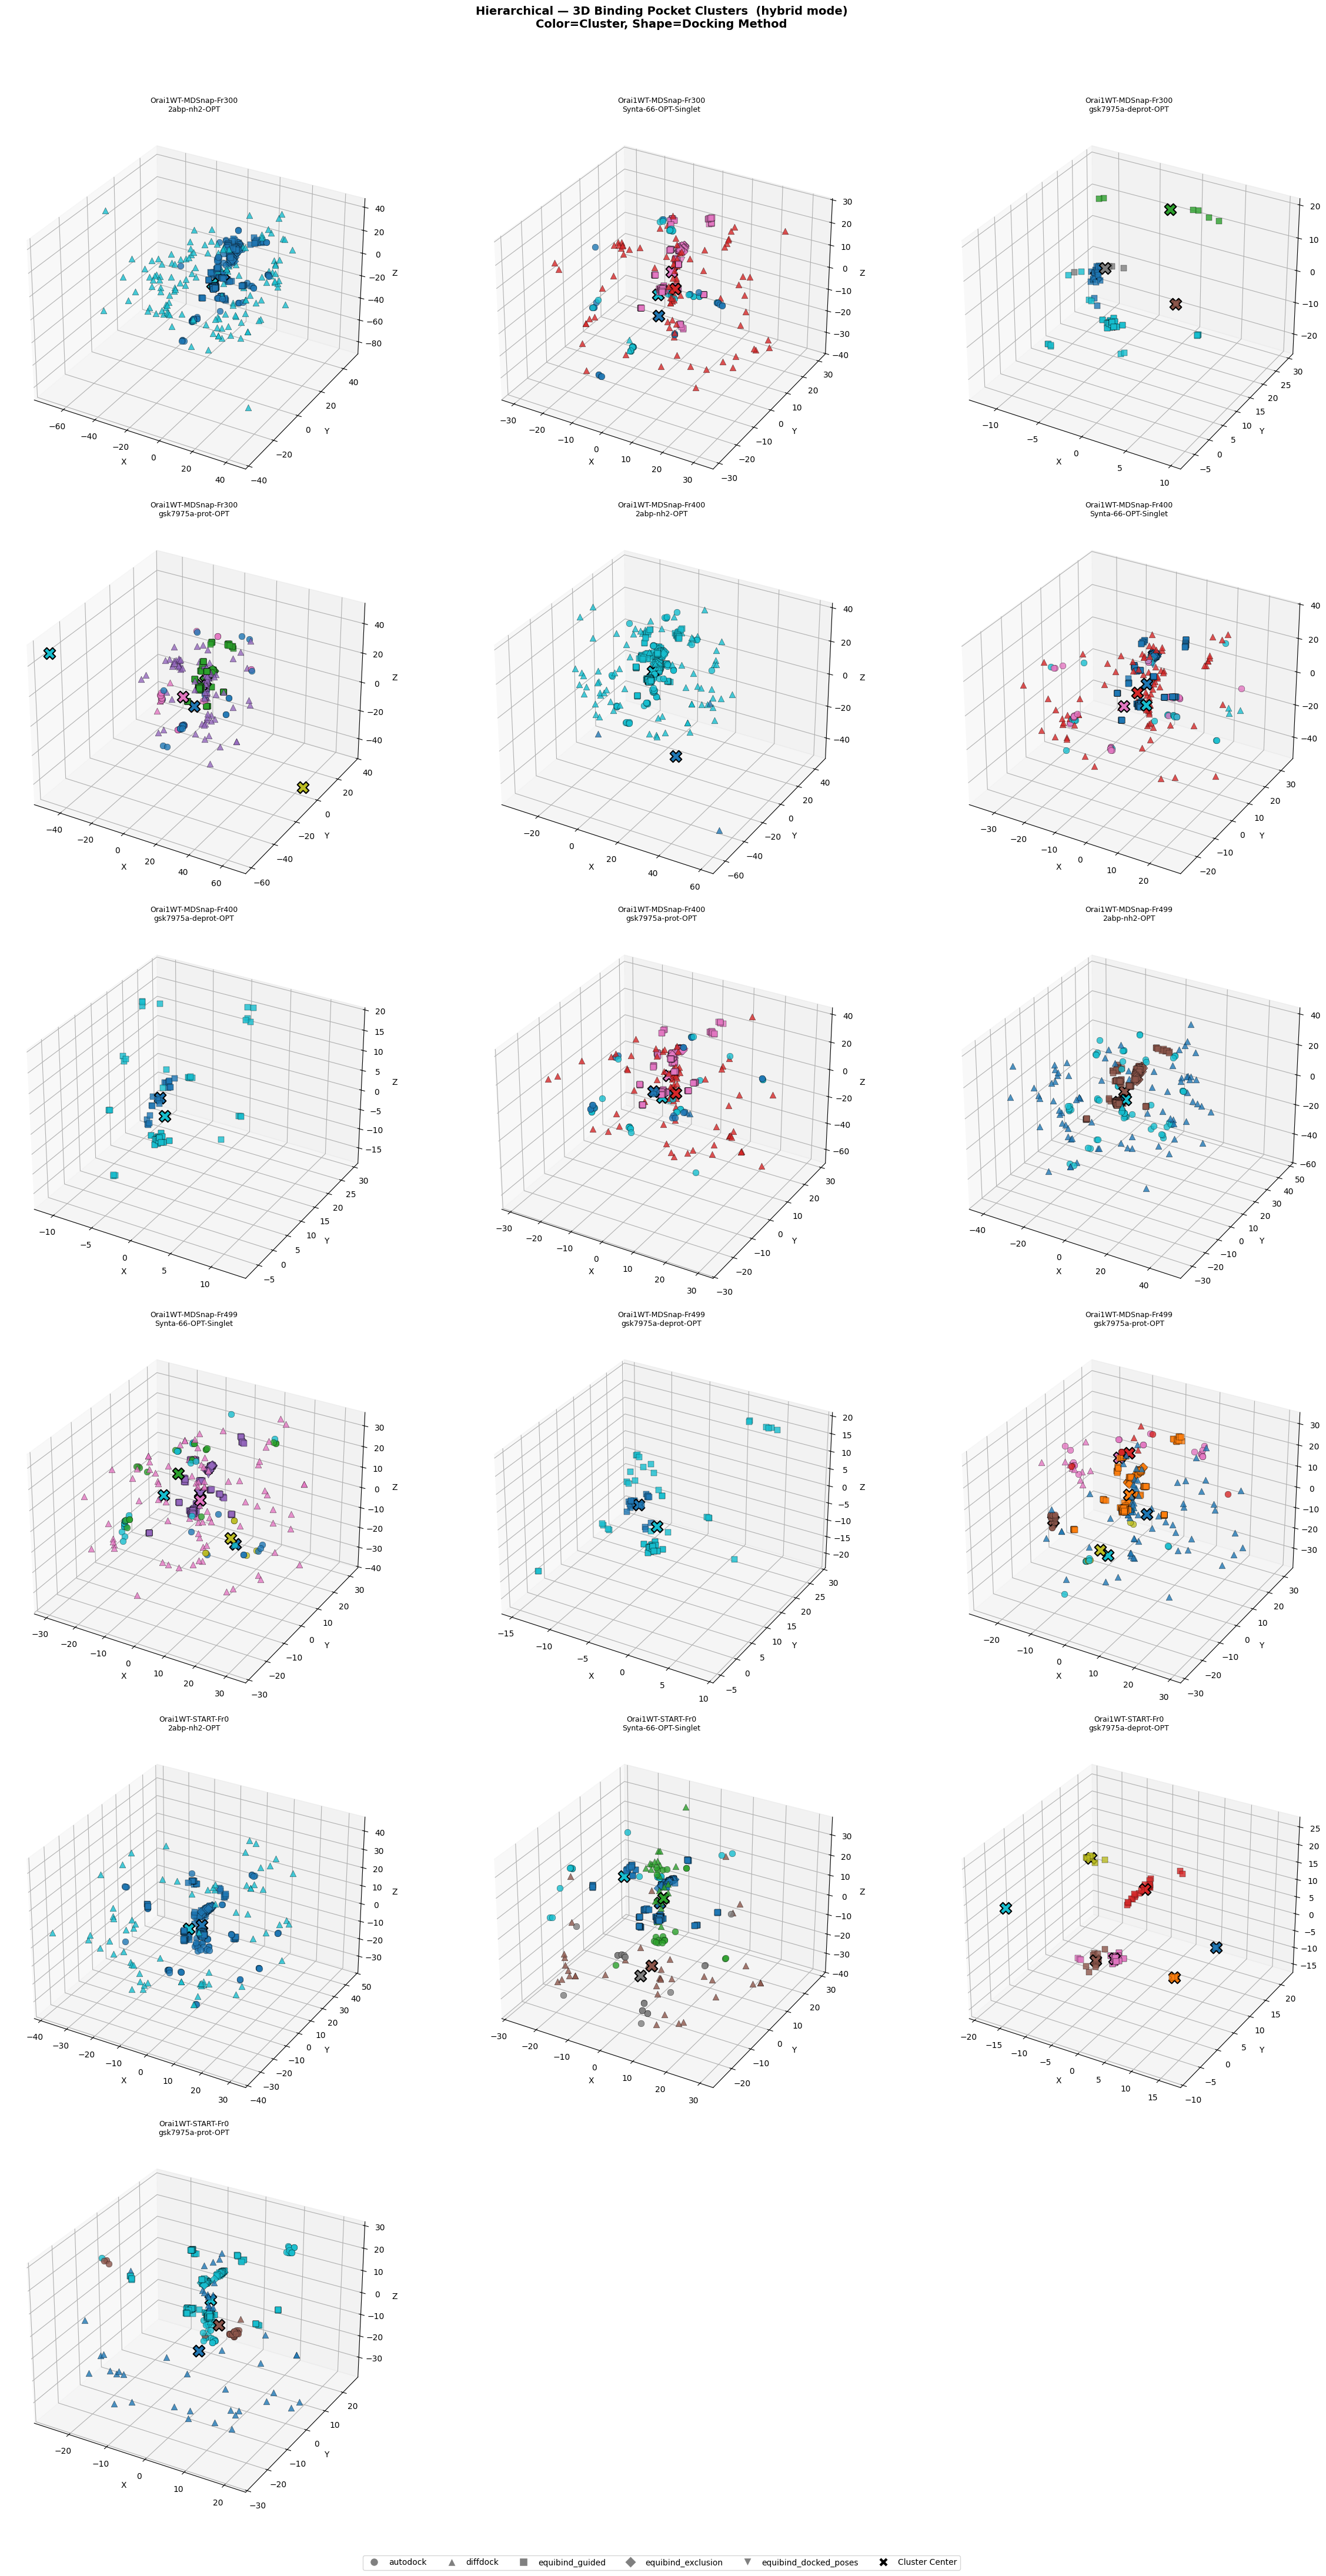

In [12]:
# ============================================================================
# 3D CLUSTER SCATTER PLOTS  (K-Medoids & Hierarchical side by side)
# ============================================================================

combo_list = list(df_clust.groupby(["protein", "ligand"]))
n_combos = len(combo_list)

for clust_col, clust_label in [("cluster_kmedoids", "K-Medoids"), ("cluster_hierarchical", "Hierarchical")]:
    n_c = 3
    n_r = (n_combos + n_c - 1) // n_c
    fig = plt.figure(figsize=(8 * n_c, 7 * n_r))
    fig.suptitle(f"{clust_label} — 3D Binding Pocket Clusters  ({DISTANCE_MODE} mode)\n"
                 "Color=Cluster, Shape=Docking Method",
                 fontsize=14, fontweight="bold", y=1.02)

    for ci, ((protein, ligand), grp) in enumerate(combo_list):
        ax = fig.add_subplot(n_r, n_c, ci + 1, projection="3d")
        ax.set_title(f"{protein}\n{ligand}", fontsize=9)

        clusters = sorted(grp[clust_col].unique())
        cmap = cm.get_cmap("tab10", max(len(clusters), 1))

        for _, row in grp.iterrows():
            c_idx = clusters.index(row[clust_col])
            ax.scatter(
                row["centroid_x"], row["centroid_y"], row["centroid_z"],
                c=[cmap(c_idx)],
                marker=METHOD_MARKERS.get(row["method"], "o"),
                s=60, alpha=0.8, edgecolors="k", linewidths=0.3,
            )

        # Cluster centers
        for cid in clusters:
            mask = grp[clust_col] == cid
            center = grp.loc[mask, ["centroid_x", "centroid_y", "centroid_z"]].mean()
            c_idx = clusters.index(cid)
            ax.scatter(center["centroid_x"], center["centroid_y"], center["centroid_z"],
                       marker="X", s=200, c=[cmap(c_idx)], edgecolors="k", linewidths=1.5)

        ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")

    legend_elements = [
        plt.Line2D([0], [0], marker=METHOD_MARKERS[m], color="w",
                   markerfacecolor="gray", markersize=10, label=m)
        for m in METHODS_LIST
    ] + [
        plt.Line2D([0], [0], marker="X", color="w", markerfacecolor="black",
                   markersize=12, label="Cluster Center"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=min(len(legend_elements), 6), fontsize=10,
               bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    fname = f"3d_clusters_{clust_label.lower().replace('-', '')}_{DISTANCE_MODE}.png"
    plt.savefig(output_dir / fname, dpi=150, bbox_inches="tight")
    plt.show()

# Heatmaps

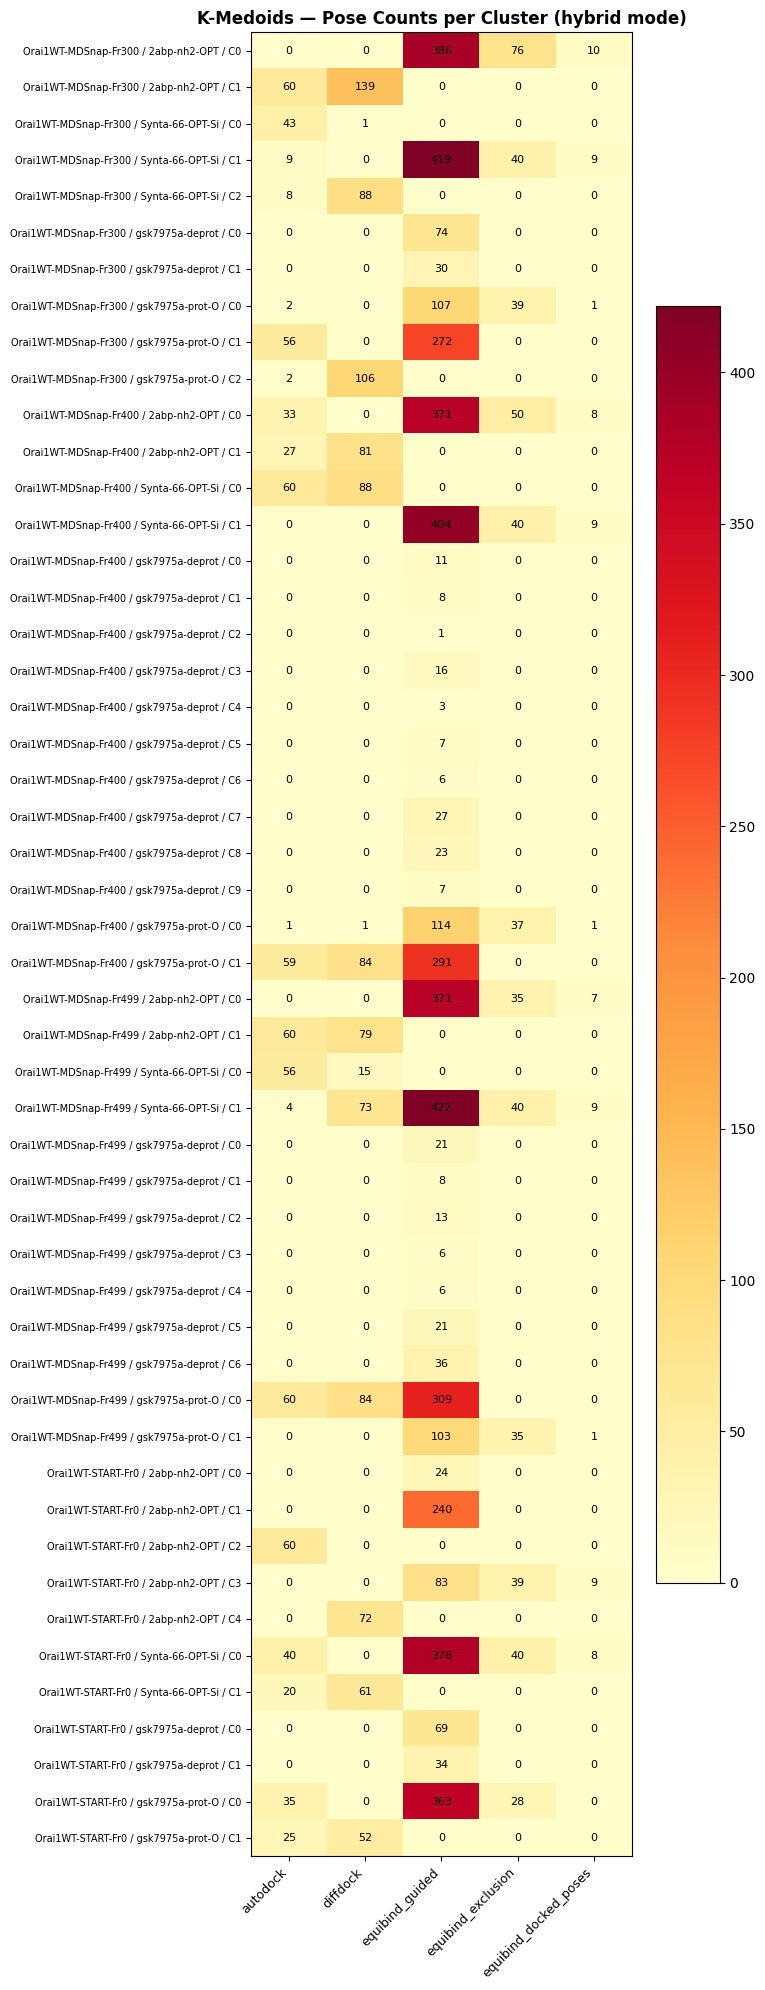

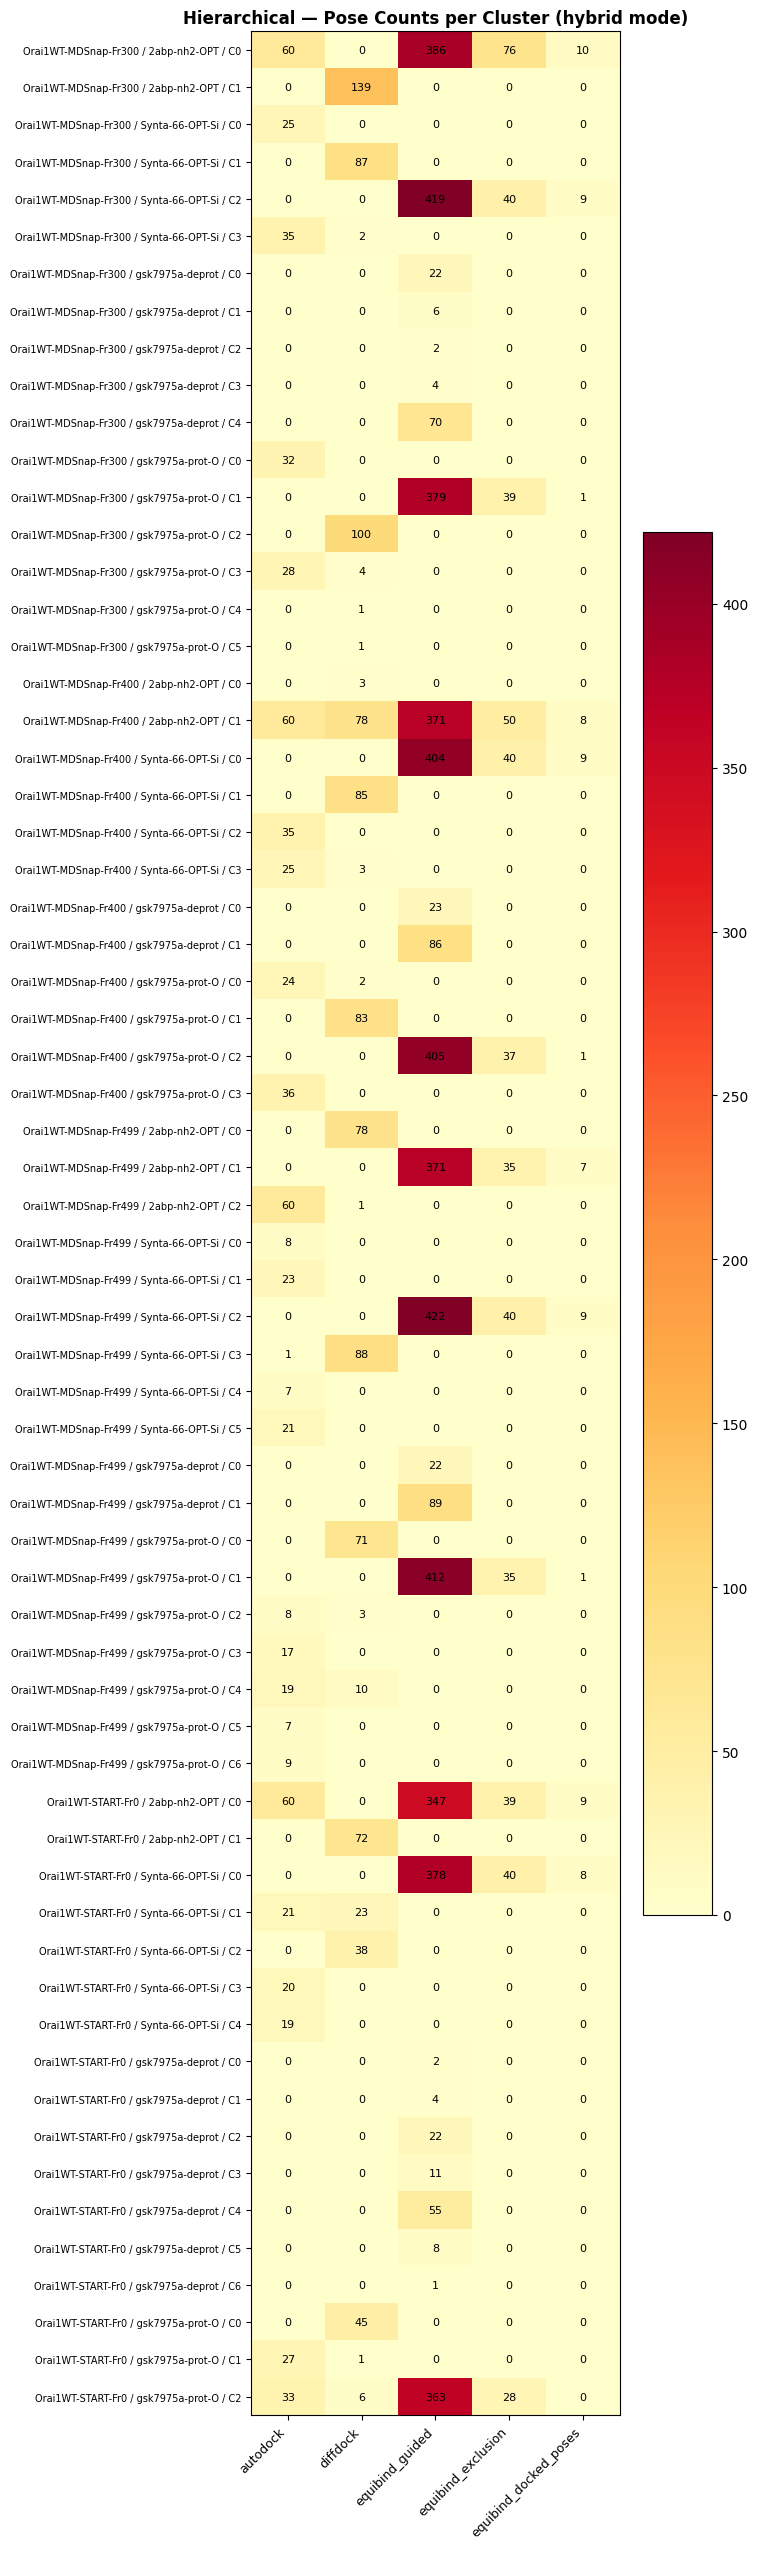

In [13]:
# ============================================================================
# POSE-COUNT HEATMAPS
# ============================================================================

for df_ov, label in [(df_km_overlap, "K-Medoids"), (df_hi_overlap, "Hierarchical")]:
    df_h = df_ov.copy()
    df_h["pocket_label"] = (
        df_h["protein"].str[:20] + " / " +
        df_h["ligand"].str[:15] + " / C" +
        df_h["cluster_id"].astype(str)
    )
    heat = df_h.set_index("pocket_label")[METHODS_LIST]

    if len(heat) > 0:
        fig, ax = plt.subplots(figsize=(max(6, len(METHODS_LIST) * 1.5), max(4, len(heat) * 0.4)))
        im = ax.imshow(heat.values, aspect="auto", cmap="YlOrRd")
        ax.set_xticks(range(len(METHODS_LIST)))
        ax.set_xticklabels(METHODS_LIST, rotation=45, ha="right", fontsize=9)
        ax.set_yticks(range(len(heat)))
        ax.set_yticklabels(heat.index, fontsize=7)
        for r in range(heat.shape[0]):
            for c in range(heat.shape[1]):
                ax.text(c, r, str(int(heat.values[r, c])), ha="center", va="center", fontsize=8)
        ax.set_title(f"{label} — Pose Counts per Cluster ({DISTANCE_MODE} mode)",
                     fontsize=12, fontweight="bold")
        plt.colorbar(im, ax=ax, shrink=0.7)
        plt.tight_layout()
        fname = f"heatmap_{label.lower().replace('-', '')}_{DISTANCE_MODE}.png"
        plt.savefig(output_dir / fname, dpi=150, bbox_inches="tight")
        plt.show()

# Cross-Method RMSD per Cluster

In [14]:
# ============================================================================
# CROSS-METHOD CLOSEST-POSE RMSD PER CLUSTER
# ============================================================================

print(f"\n{'='*100}")
print("CROSS-METHOD RMSD PER CLUSTER")
print(f"{'='*100}")

_ABBR = {m: m[:2].upper() for m in METHODS_LIST}

rmsd_rows = []

for clust_col, clust_label in [("cluster_kmedoids", "K-Medoids"), ("cluster_hierarchical", "Hierarchical")]:
    for (protein, ligand), grp in df_clust.groupby(["protein", "ligand"]):
        for cid in sorted(grp[clust_col].unique()):
            cg = grp[grp[clust_col] == cid]
            methods_present = sorted(cg["method"].unique())
            if len(methods_present) < 2:
                continue

            for m1, m2 in combinations(methods_present, 2):
                files_1 = cg[cg["method"] == m1]["file_path"].tolist()
                files_2 = cg[cg["method"] == m2]["file_path"].tolist()

                best_rmsd = np.inf
                for f1 in files_1:
                    mol1 = loaded_mols.get(f1)
                    if mol1 is None:
                        continue
                    for f2 in files_2:
                        mol2 = loaded_mols.get(f2)
                        if mol2 is None:
                            continue
                        r = compute_heavy_atom_rmsd(mol1, mol2)
                        if np.isfinite(r) and r < best_rmsd:
                            best_rmsd = r
                if np.isfinite(best_rmsd):
                    rmsd_rows.append({
                        "cluster_method": clust_label,
                        "protein": protein, "ligand": ligand,
                        "cluster_id": cid,
                        "method_1": _ABBR[m1], "method_2": _ABBR[m2],
                        "closest_rmsd_A": round(best_rmsd, 2),
                    })

df_xrmsd = pd.DataFrame(rmsd_rows)
if df_xrmsd.empty:
    print("  No multi-method clusters found.")
else:
    print(df_xrmsd.to_string(index=False))


CROSS-METHOD RMSD PER CLUSTER
cluster_method              protein               ligand  cluster_id method_1 method_2  closest_rmsd_A
     K-Medoids Orai1WT-MDSnap-Fr300         2abp-nh2-OPT           0       EQ       EQ            0.59
     K-Medoids Orai1WT-MDSnap-Fr300         2abp-nh2-OPT           0       EQ       EQ            0.45
     K-Medoids Orai1WT-MDSnap-Fr300         2abp-nh2-OPT           0       EQ       EQ            0.44
     K-Medoids Orai1WT-MDSnap-Fr300         2abp-nh2-OPT           1       AU       DI           61.51
     K-Medoids Orai1WT-MDSnap-Fr300 Synta-66-OPT-Singlet           0       AU       DI           42.19
     K-Medoids Orai1WT-MDSnap-Fr300 Synta-66-OPT-Singlet           1       AU       EQ           36.38
     K-Medoids Orai1WT-MDSnap-Fr300 Synta-66-OPT-Singlet           1       AU       EQ           36.38
     K-Medoids Orai1WT-MDSnap-Fr300 Synta-66-OPT-Singlet           1       AU       EQ           40.66
     K-Medoids Orai1WT-MDSnap-Fr300 Synta-

# K-Medoids vs Hierarchical Comparison

In [15]:
# ============================================================================
# K-MEDOIDS vs HIERARCHICAL AGREEMENT
# ============================================================================

print(f"\n{'='*100}")
print(f"K-MEDOIDS vs HIERARCHICAL AGREEMENT  (mode={DISTANCE_MODE})")
print(f"{'='*100}")

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

agree_rows = []
for (protein, ligand), grp in df_clust.groupby(["protein", "ligand"]):
    lab_km = grp["cluster_kmedoids"].values
    lab_hi = grp["cluster_hierarchical"].values
    ari = adjusted_rand_score(lab_km, lab_hi) if len(set(lab_km)) > 1 and len(set(lab_hi)) > 1 else np.nan
    nmi = normalized_mutual_info_score(lab_km, lab_hi) if len(set(lab_km)) > 1 and len(set(lab_hi)) > 1 else np.nan
    agree_rows.append({
        "protein": protein, "ligand": ligand,
        "k_kmedoids": grp["cluster_kmedoids"].nunique(),
        "k_hierarchical": grp["cluster_hierarchical"].nunique(),
        "ARI": round(ari, 3) if np.isfinite(ari) else "N/A",
        "NMI": round(nmi, 3) if np.isfinite(nmi) else "N/A",
        "n_poses": len(grp),
    })

df_agree = pd.DataFrame(agree_rows)
print(df_agree.to_string(index=False))


K-MEDOIDS vs HIERARCHICAL AGREEMENT  (mode=hybrid)
             protein               ligand  k_kmedoids  k_hierarchical    ARI   NMI  n_poses
Orai1WT-MDSnap-Fr300         2abp-nh2-OPT           2               2  0.654 0.588      671
Orai1WT-MDSnap-Fr300 Synta-66-OPT-Singlet           3               4  0.935 0.842      617
Orai1WT-MDSnap-Fr300  gsk7975a-deprot-OPT           2               5  0.619 0.502      104
Orai1WT-MDSnap-Fr300    gsk7975a-prot-OPT           3               6  0.340 0.509      585
Orai1WT-MDSnap-Fr400         2abp-nh2-OPT           2               2  0.034 0.034      570
Orai1WT-MDSnap-Fr400 Synta-66-OPT-Singlet           2               4  0.926 0.823      601
Orai1WT-MDSnap-Fr400  gsk7975a-deprot-OPT          10               2  0.161 0.404      109
Orai1WT-MDSnap-Fr400    gsk7975a-prot-OPT           2               4 -0.115 0.107      588
Orai1WT-MDSnap-Fr499         2abp-nh2-OPT           2               3  0.934 0.867      552
Orai1WT-MDSnap-Fr499 Synta-6

# Save All Results

In [16]:
# ============================================================================
# SAVE ALL OUTPUT
# ============================================================================

# Poses with cluster labels
csv_poses = output_dir / f"clustering_{DISTANCE_MODE}_all_poses.csv"
df_clust.to_csv(csv_poses, index=False)
print(f"  Saved: {csv_poses}")

# K-Medoids pocket stats
csv_km = output_dir / f"clustering_{DISTANCE_MODE}_kmedoids_pockets.csv"
df_km_overlap.to_csv(csv_km, index=False)
print(f"  Saved: {csv_km}")

# Hierarchical pocket stats
csv_hi = output_dir / f"clustering_{DISTANCE_MODE}_hierarchical_pockets.csv"
df_hi_overlap.to_csv(csv_hi, index=False)
print(f"  Saved: {csv_hi}")

# Conformity scores
csv_scores = output_dir / f"clustering_{DISTANCE_MODE}_conformity_scores.csv"
df_scores.to_csv(csv_scores, index=False)
print(f"  Saved: {csv_scores}")

# Cross-method RMSD
if not df_xrmsd.empty:
    csv_xrmsd = output_dir / f"clustering_{DISTANCE_MODE}_cross_method_rmsd.csv"
    df_xrmsd.to_csv(csv_xrmsd, index=False)
    print(f"  Saved: {csv_xrmsd}")

# Agreement
csv_agree = output_dir / f"clustering_{DISTANCE_MODE}_agreement.csv"
df_agree.to_csv(csv_agree, index=False)
print(f"  Saved: {csv_agree}")

# ── Summary JSON ──
import json
summary = {
    "distance_mode": DISTANCE_MODE,
    "hybrid_weight_rmsd": HYBRID_WEIGHT_RMSD if DISTANCE_MODE == "hybrid" else None,
    "methods": METHODS_LIST,
    "n_combos": n_combos,
    "total_poses": len(df_clust),
    "kmedoids": {ck: {"k": v["optimal_k"], "silhouette": round(v["best_silhouette"], 3)}
                 for ck, v in km_info.items()},
    "hierarchical": {ck: {"k": v["optimal_k"], "silhouette": round(v["best_silhouette"], 3)}
                     for ck, v in hi_info.items()},
}
json_path = output_dir / f"clustering_{DISTANCE_MODE}_summary.json"
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"  Saved: {json_path}")

print(f"\n{'='*100}")
print("ALL DONE")
print(f"{'='*100}")

  Saved: /home/manndo/master_dev/posebusters_results/clustering_v3_results/hybrid/clustering_hybrid_all_poses.csv
  Saved: /home/manndo/master_dev/posebusters_results/clustering_v3_results/hybrid/clustering_hybrid_kmedoids_pockets.csv
  Saved: /home/manndo/master_dev/posebusters_results/clustering_v3_results/hybrid/clustering_hybrid_hierarchical_pockets.csv
  Saved: /home/manndo/master_dev/posebusters_results/clustering_v3_results/hybrid/clustering_hybrid_conformity_scores.csv
  Saved: /home/manndo/master_dev/posebusters_results/clustering_v3_results/hybrid/clustering_hybrid_cross_method_rmsd.csv
  Saved: /home/manndo/master_dev/posebusters_results/clustering_v3_results/hybrid/clustering_hybrid_agreement.csv
  Saved: /home/manndo/master_dev/posebusters_results/clustering_v3_results/hybrid/clustering_hybrid_summary.json

ALL DONE
